# Mini Project

## Stage 1

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Load dataset

In [2]:
df = pd.read_csv("loan_data.csv")
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


### Basic inspection

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

Shape of dataset: (45000, 14)

Columns:
 ['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']

Data types:

Age                      int64
Gender                     str
Education                  str
Person Income            int64
Employee Experience      int64
Home Onwership             str
Loan Amount              int64
Loan Intent                str
Loan interest Rate     float64
Loan percentage        float64
Credit History           int64
Credit Score             int64
Previous Loan              str
Loan Status              int64
dtype: object


### Rename columns for easier coding

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_onwership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='str')

### Preview after renaming

In [6]:
df.head()

,age,gender,education,person_income,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


### Missing values and duplicates

In [7]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

age                    0
gender                 0
education              0
person_income          0
employee_experience    0
home_onwership         0
loan_amount            0
loan_intent            0
loan_interest_rate     0
loan_percentage        0
credit_history         0
credit_score           0
previous_loan          0
loan_status            0
dtype: int64

Duplicate rows: 0


### Basic statistical summary

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45000.0,NaN,NaN,NaN,27.764178,6.045108,20.0,24.0,26.0,30.0,144.0
gender,45000,2,male,24841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45000,5,Bachelor,13399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_income,45000.0,NaN,NaN,NaN,80319.053222,80422.498632,8000.0,47204.0,67048.0,95789.25,7200766.0
employee_experience,45000.0,NaN,NaN,NaN,5.410333,6.063532,0.0,1.0,4.0,8.0,125.0
home_onwership,45000,4,RENT,23443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,45000.0,NaN,NaN,NaN,9583.157556,6314.886691,500.0,5000.0,8000.0,12237.25,35000.0
loan_intent,45000,6,EDUCATION,9153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_interest_rate,45000.0,NaN,NaN,NaN,11.006606,2.978808,5.42,8.59,11.01,12.99,20.0
loan_percentage,45000.0,NaN,NaN,NaN,0.139725,0.087212,0.0,0.07,0.12,0.19,0.66


### Target analysis

In [9]:
print(df["loan_status"].value_counts())

print("\nClass Percentage:\n")
print(df["loan_status"].value_counts(normalize=True) * 100)

loan_status
0    35000
1    10000
Name: count, dtype: int64

Class Percentage:

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


### Average values grouped by target

In [10]:
print(df["loan_status"].value_counts())

print("\nAverage values grouped by loan_status:\n")
print(
    df.groupby("loan_status")[[
        "person_income",
        "credit_score",
        "loan_interest_rate",
        "loan_percentage",
        "credit_history"
    ]].mean()
)

loan_status
0    35000
1    10000
Name: count, dtype: int64

Average values grouped by loan_status:

             person_income  credit_score  loan_interest_rate  loan_percentage  \
loan_status                                                                     
0             86157.040743    632.814914           10.477981         0.121783   
1             59886.096900    631.887200           12.856794         0.202521   

             credit_history  
loan_status                  
0                  5.898286  
1                  5.759700  


### Target visualization

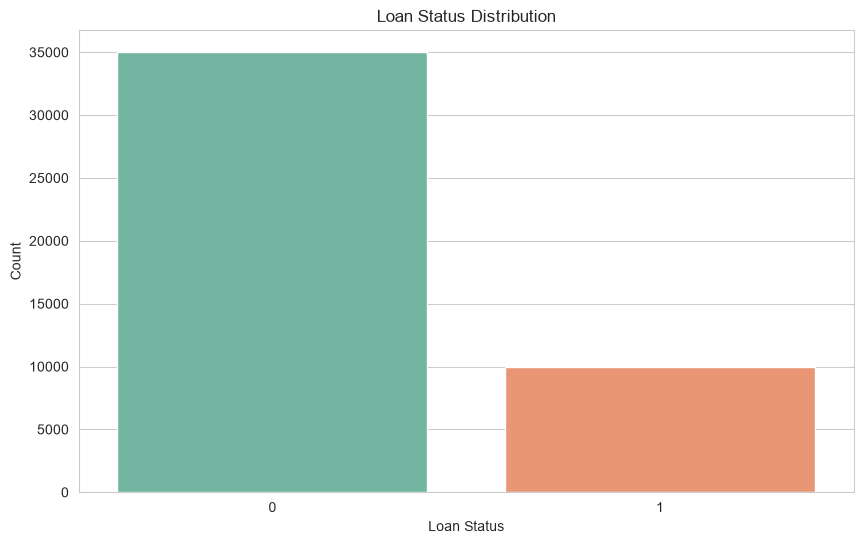

In [11]:
sns.countplot(x="loan_status", data=df, palette="Set2")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

In [12]:
# The target variable loan_status is imbalanced because class 0 has significantly
# more samples than class 1. So imbalance handling will be added in Stage 2.

### Separate categorical and numerical columns

In [13]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:\n", categorical_cols)
print("\nNumerical columns:\n", numerical_cols)

Categorical columns:
 ['gender', 'education', 'home_onwership', 'loan_intent', 'previous_loan']

Numerical columns:
 ['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'loan_status']


### Univariate analysis

### Histograms for numeric features

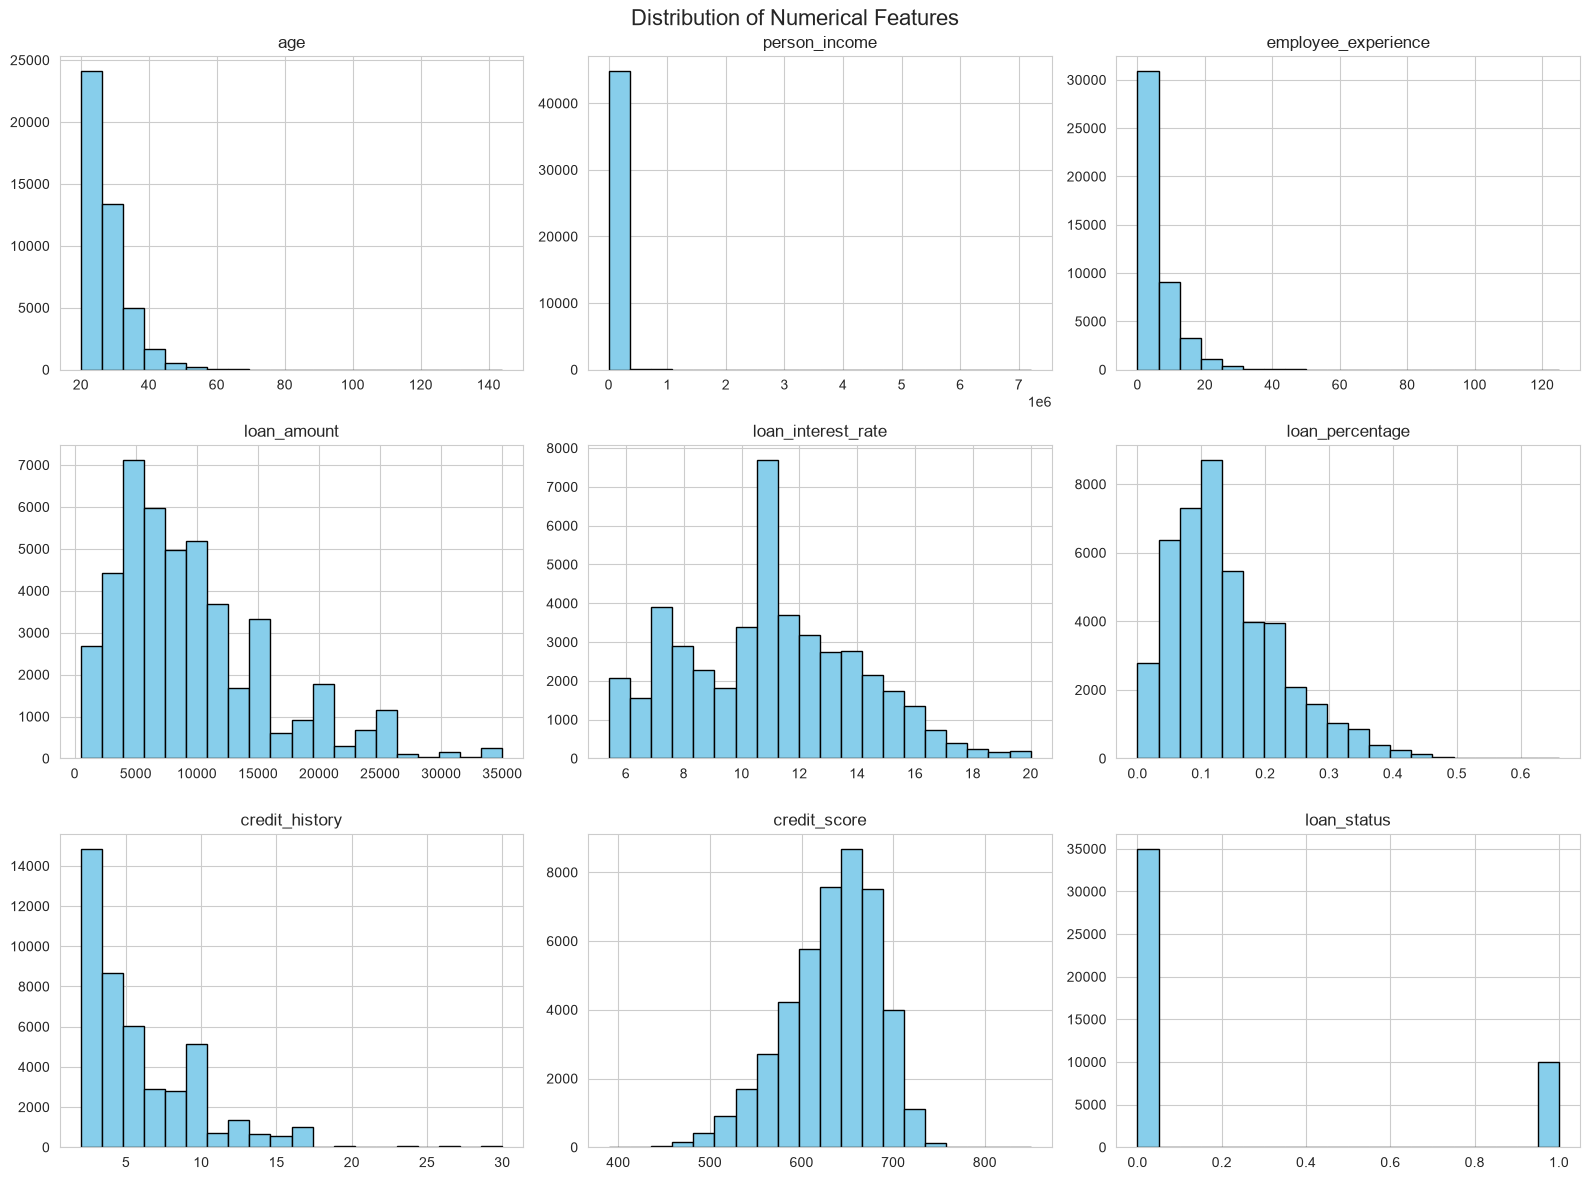

In [14]:
df[numerical_cols].hist(bins=20, figsize=(16, 12), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Count plots for categorical features

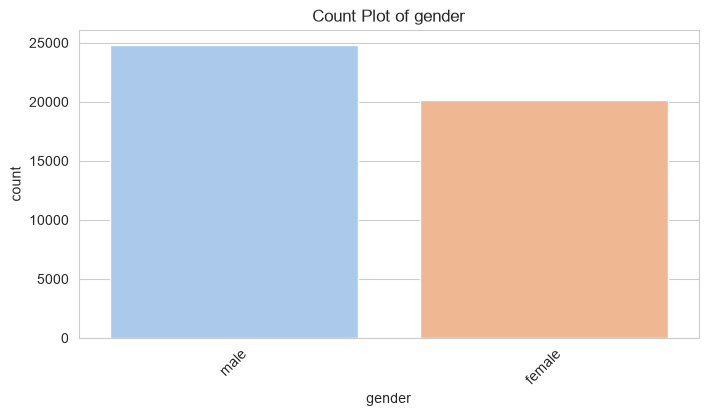

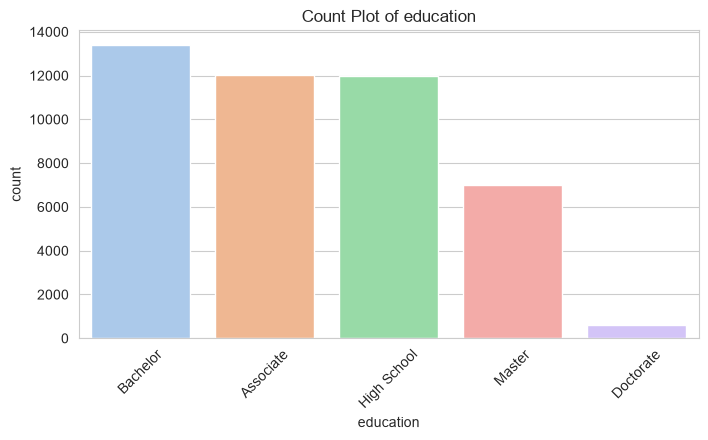

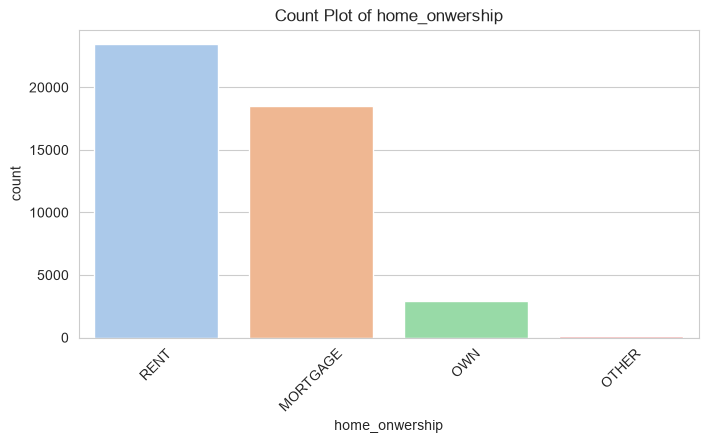

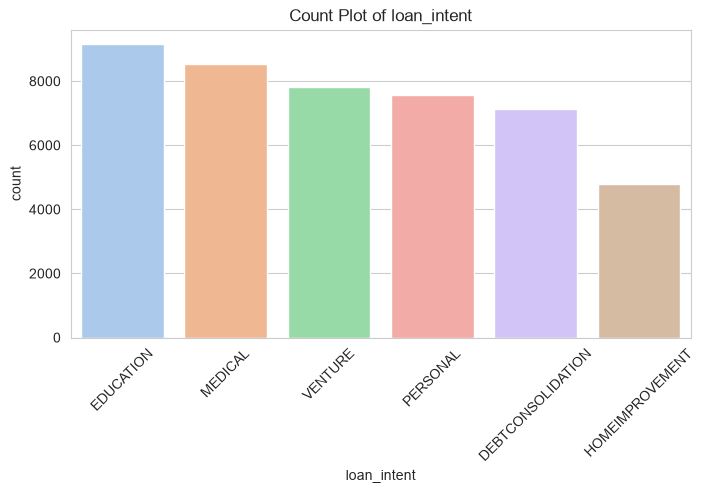

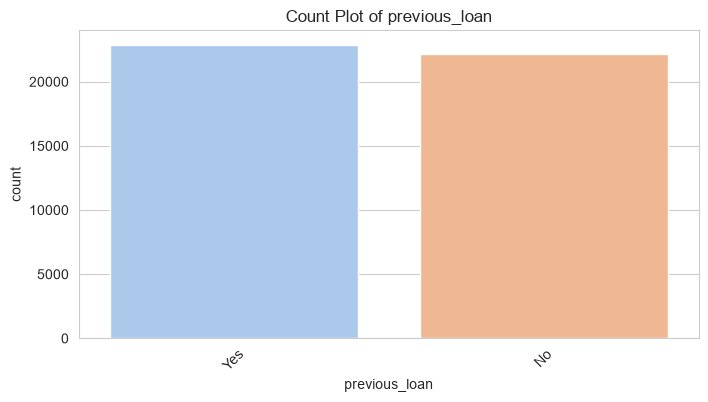

In [15]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, palette="pastel", order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

### Bivariate analysis

### Numerical features vs target

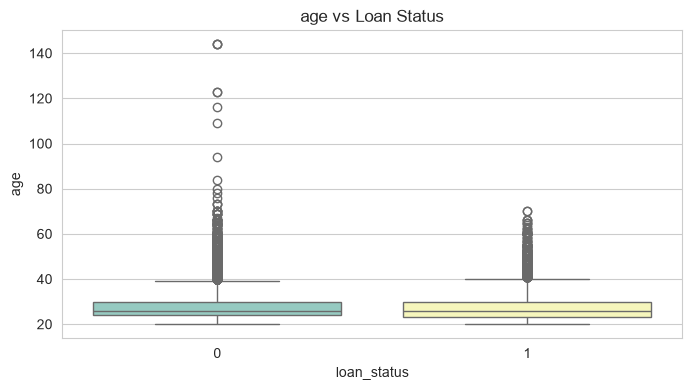

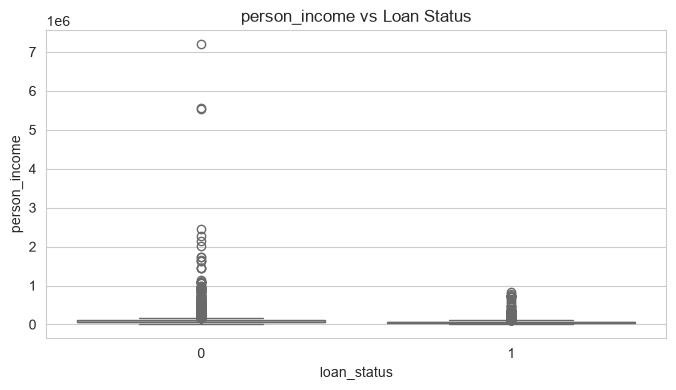

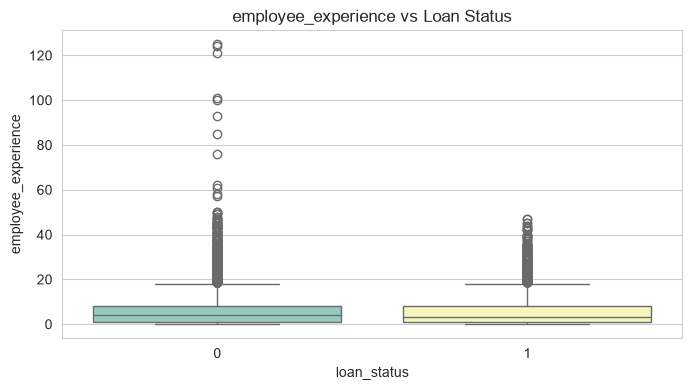

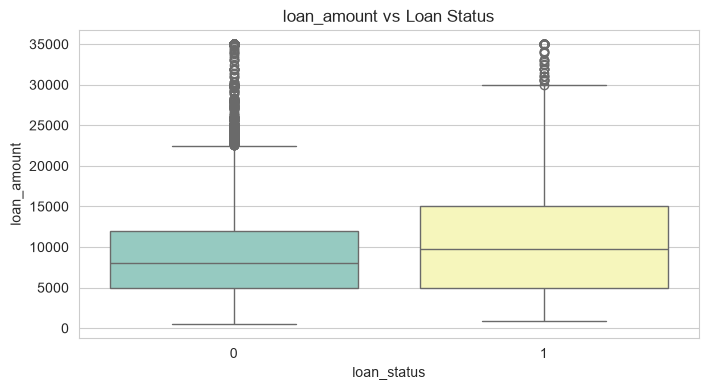

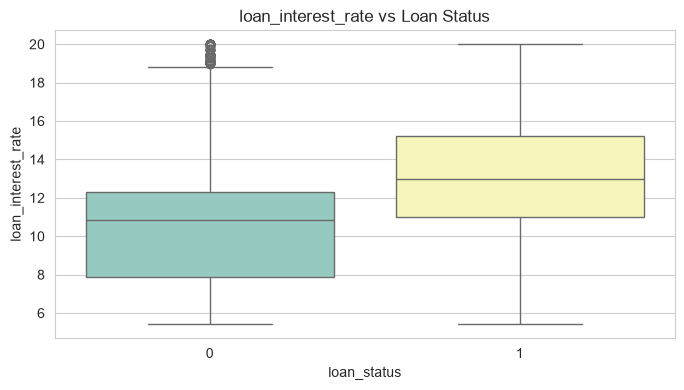

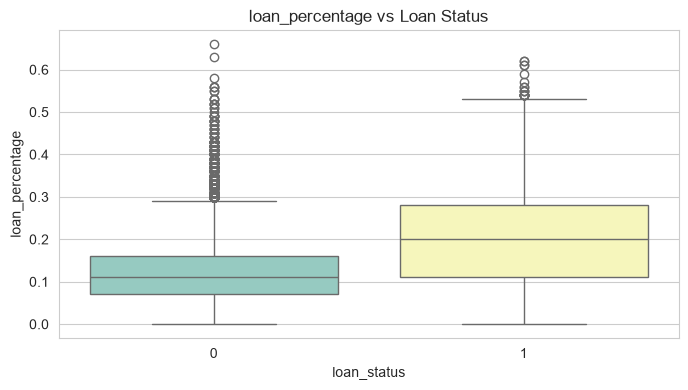

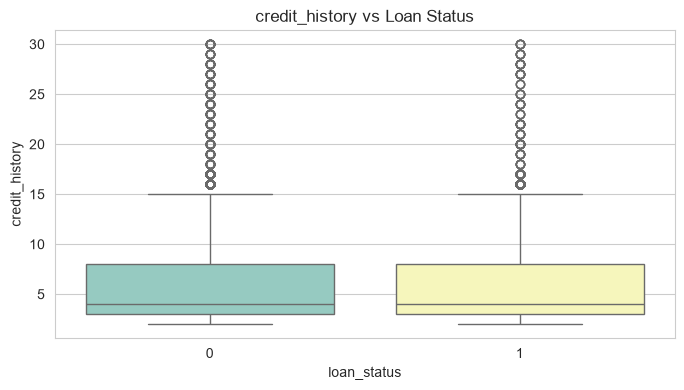

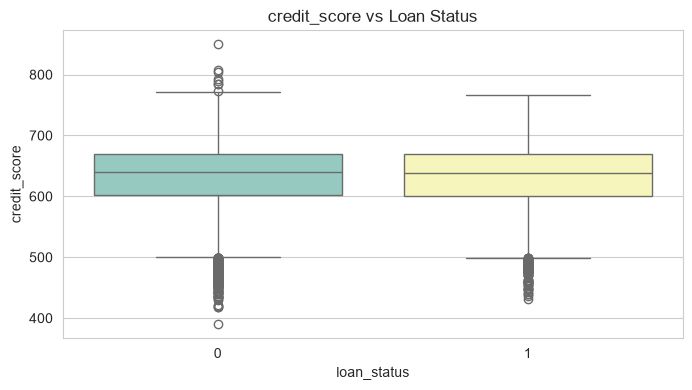

In [16]:
num_features_for_box = [col for col in numerical_cols if col != "loan_status"]

for col in num_features_for_box:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="loan_status", y=col, data=df, palette="Set3")
    plt.title(f"{col} vs Loan Status")
    plt.show()

In [17]:
### Categorical features vs target

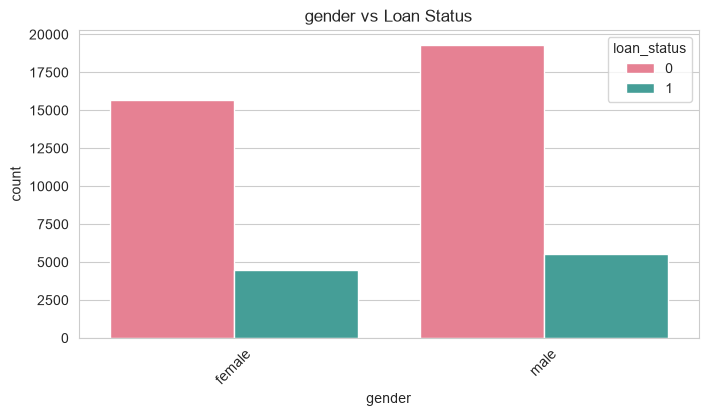

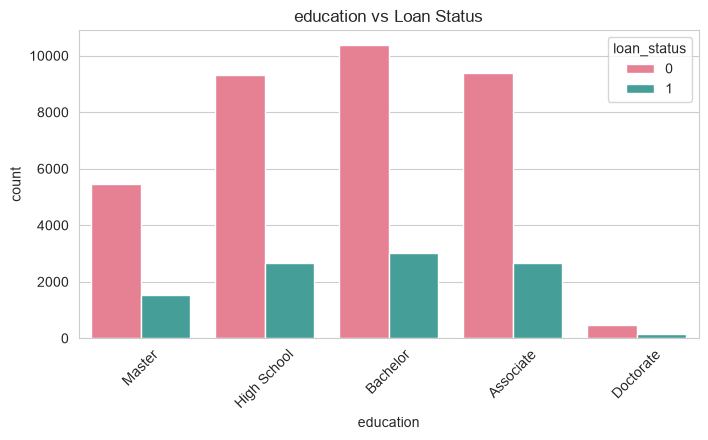

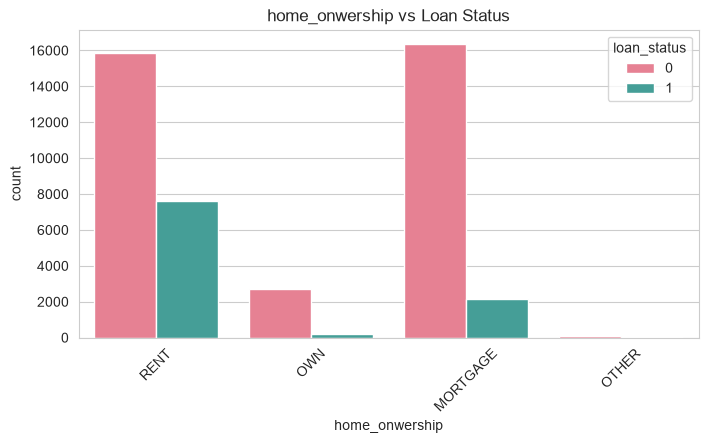

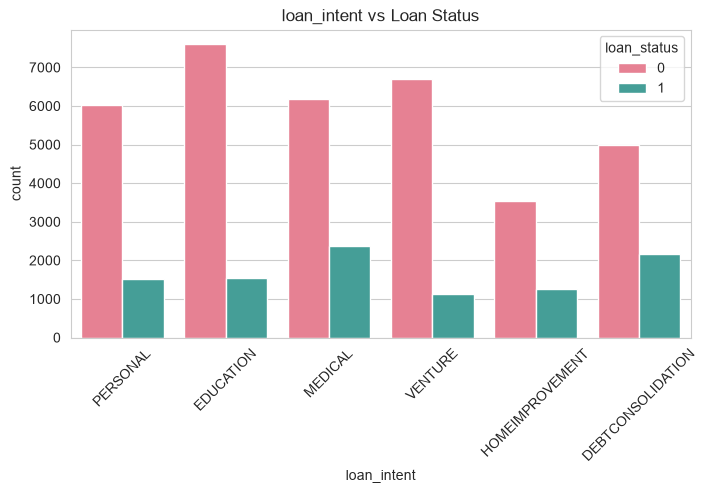

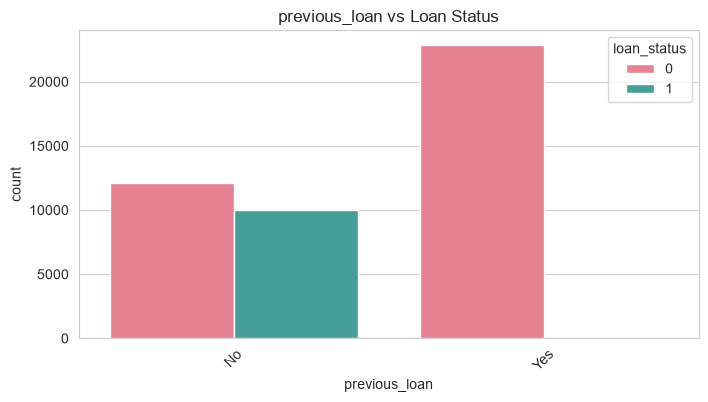

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="loan_status", data=df, palette="husl")
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

### Correlation heatmap

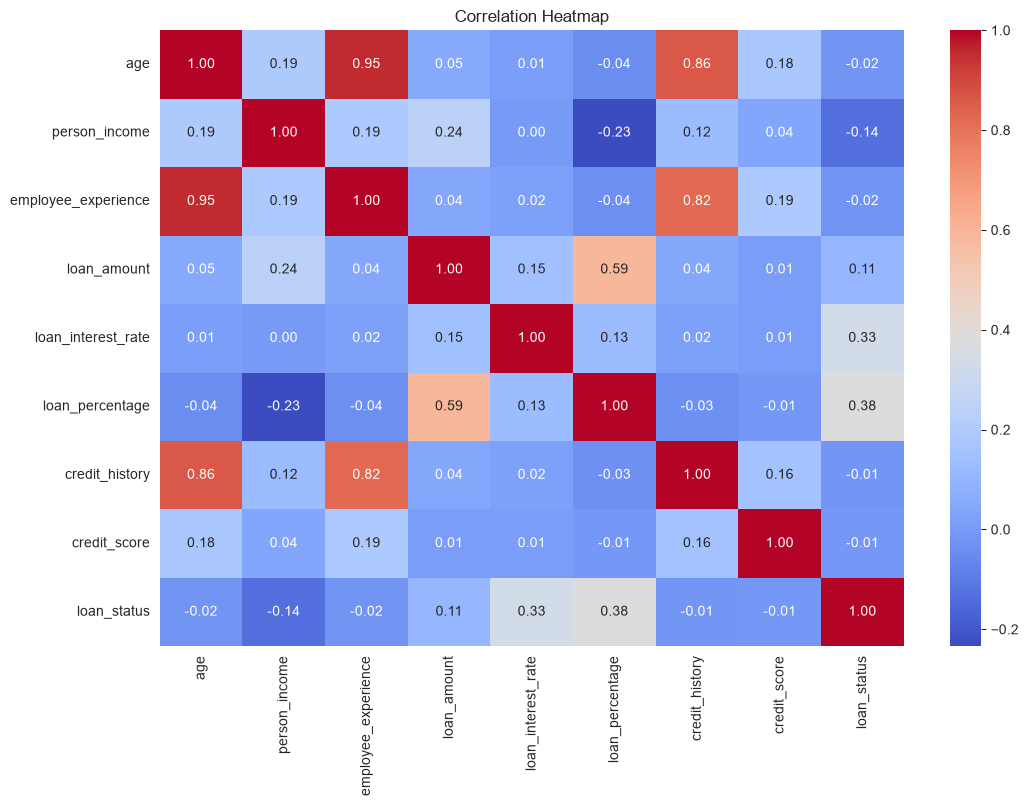

In [19]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Check suspicious rows

In [20]:
print("Age > 80")
display(df[df["age"] > 80][["age", "employee_experience", "person_income", "loan_status"]])

print("Employee Experience > 50")
display(df[df["employee_experience"] > 50][["age", "employee_experience", "person_income", "loan_status"]])

Age > 80


,age,employee_experience,person_income,loan_status
81,144,125,300616,0
183,144,121,241424,0
575,123,101,97140,0
747,123,100,94723,0
32297,144,124,7200766,0
32416,94,76,29738,0
32506,84,61,114705,0
37930,116,93,5545545,0
38113,109,85,5556399,0


Employee Experience > 50


,age,employee_experience,person_income,loan_status
81,144,125,300616,0
183,144,121,241424,0
575,123,101,97140,0
747,123,100,94723,0
32297,144,124,7200766,0
32355,78,57,58463,0
32416,94,76,29738,0
32422,80,62,77894,0
32506,84,61,114705,0
32534,76,58,90934,0


### Remove impossible values

In [21]:
df = df[(df["age"] >= 18) & (df["age"] <= 80)]
df = df[(df["employee_experience"] >= 0) & (df["employee_experience"] <= 60)]

print("Shape after removing impossible age and experience values:", df.shape)

Shape after removing impossible age and experience values: (44990, 14)


### Recheck summary

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,44990.0,27.744543,5.890563,20.00,24.00,26.00,30.00,78.00
person_income,44990.0,79908.834074,63323.588584,8000.00,47195.75,67045.50,95777.00,2448661.00
employee_experience,44990.0,5.390465,5.906165,0.00,1.00,4.00,8.00,58.00
loan_amount,44990.0,9583.297888,6314.982527,500.00,5000.00,8000.00,12237.75,35000.00
loan_interest_rate,44990.0,11.006510,2.979037,5.42,8.59,11.01,12.99,20.00
loan_percentage,44990.0,0.139737,0.087208,0.00,0.07,0.12,0.19,0.66
credit_history,44990.0,5.865259,3.874023,2.00,3.00,4.00,8.00,30.00
credit_score,44990.0,632.578329,50.394327,390.00,601.00,640.00,670.00,784.00
loan_status,44990.0,0.222272,0.415777,0.00,0.00,0.00,0.00,1.00


### Recheck age and experience boxplots

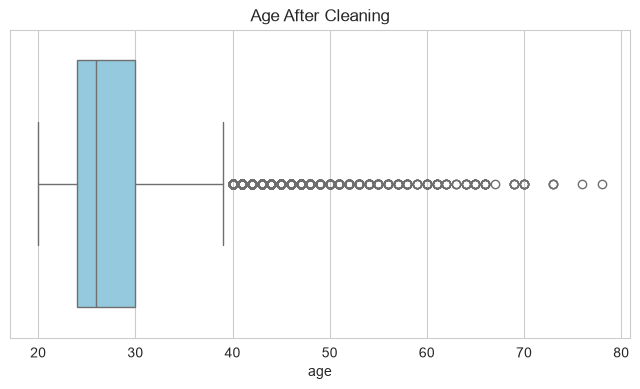

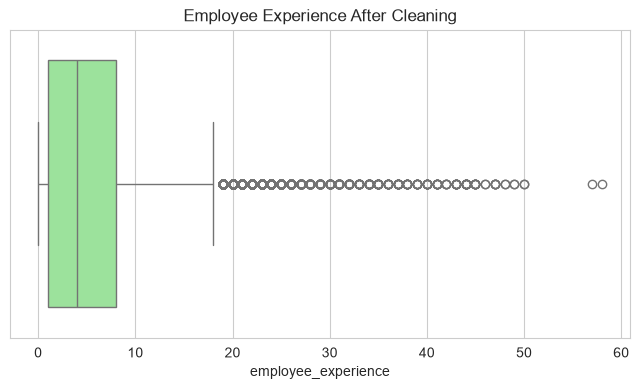

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["age"], color="skyblue")
plt.title("Age After Cleaning")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["employee_experience"], color="lightgreen")
plt.title("Employee Experience After Cleaning")
plt.show()

### Person income distribution check

In [24]:
df["person_income"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count    4.499000e+04
mean     7.990883e+04
std      6.332359e+04
min      8.000000e+03
90%      1.332472e+05
95%      1.666986e+05
99%      2.712688e+05
99.5%    3.607275e+05
99.9%    7.643604e+05
max      2.448661e+06
Name: person_income, dtype: float64

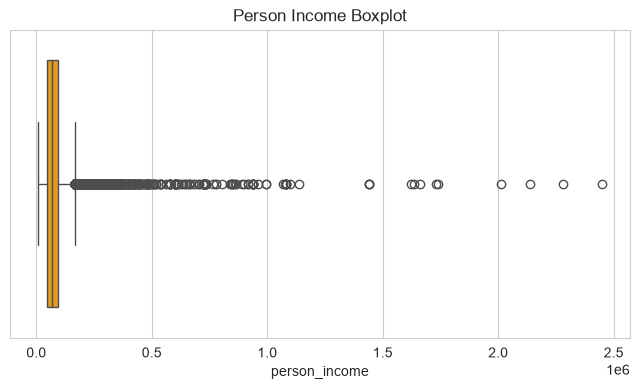

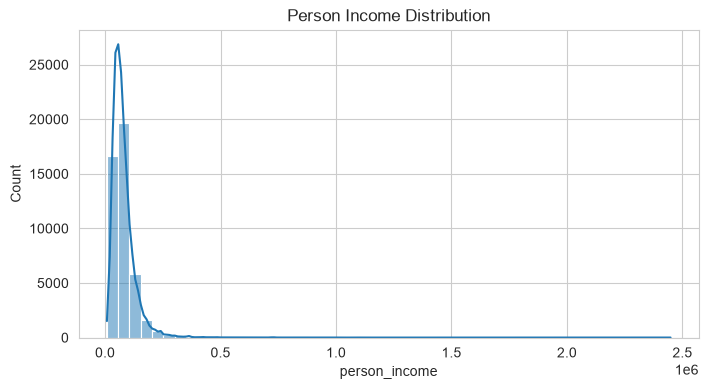

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["person_income"], color="orange")
plt.title("Person Income Boxplot")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df["person_income"], bins=50, kde=True)
plt.title("Person Income Distribution")
plt.show()

### Log transformation of income

In [27]:
# The person_income variable is strongly right-skewed and contains many high-income outliers.
# Applying log transformation reduces skewness and improves model learning.

df["person_income_log"] = np.log1p(df["person_income"])

### Drop original income column

In [28]:
# Keep log-transformed income and remove original income
df = df.drop("person_income", axis=1)
df.head()

,age,gender,education,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status,person_income_log
0,22,female,Master,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1,11.183713
1,21,female,High School,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0,9.415971
2,25,female,High School,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1,9.428592
3,23,female,Bachelor,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1,11.286702
4,24,male,Master,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1,11.099469


### Preprocessing

In [29]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = df.copy()
label_encoders = {}

Categorical columns: ['gender', 'education', 'home_onwership', 'loan_intent', 'previous_loan']


### Label encoding

In [31]:
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,age,gender,education,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status,person_income_log
0,22,0,4,0,3,35000,4,16.02,0.49,3,561,0,1,11.183713
1,21,0,3,0,2,1000,1,11.14,0.08,2,504,1,0,9.415971
2,25,0,3,3,0,5500,3,12.87,0.44,3,635,0,1,9.428592
3,23,0,1,0,3,35000,3,15.23,0.44,2,675,0,1,11.286702
4,24,1,4,1,3,35000,3,14.27,0.53,4,586,0,1,11.099469


### Feature and target split

In [32]:
X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44990, 13)
y shape: (44990,)


### Train-test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (35992, 13)
X_test shape: (8998, 13)
y_train distribution:
 loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64
y_test distribution:
 loan_status
0    0.777728
1    0.222272
Name: proportion, dtype: float64


### Scale numeric features

In [34]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_features_only = X.select_dtypes(include=np.number).columns.tolist()

X_train_scaled[numeric_features_only] = scaler.fit_transform(X_train[numeric_features_only])
X_test_scaled[numeric_features_only] = scaler.transform(X_test[numeric_features_only])

X_train_scaled.head()

,age,gender,education,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,person_income_log
35130,-0.806911,0.902789,-1.178204,-0.914836,0.212348,-0.948261,-0.885908,-1.524854,-0.913892,-0.741596,-1.359661,-1.016303,-0.187739
42030,-0.467302,-1.107679,1.526557,-0.406832,0.906394,-1.361283,0.271170,0.186171,-1.259106,-0.483370,1.177577,-1.016303,-1.197441
423,-0.467302,0.902789,-0.502014,-0.237498,0.906394,2.292378,-0.885908,-1.347041,1.847821,-0.741596,-0.606419,-1.016303,0.309268
29022,1.060938,0.902789,1.526557,0.947845,0.212348,0.068410,-0.307369,-0.692826,0.812178,0.807760,1.355977,-1.016303,-0.662977
6629,-0.297497,0.902789,0.850367,-0.745502,0.906394,-0.567009,-1.464447,-1.749635,-0.453607,-0.483370,-0.170331,0.983958,-0.136635


### Summary

In [35]:
print("Summary")
print("The dataset was loaded and cleaned successfully.")
print("Column names were standardized for easier notebook use.")
print("Missing values, duplicates, feature distributions, and target balance were examined.")
print("Visualizations were created for univariate and bivariate analysis.")
print("Categorical features were encoded and the data was split into training and testing sets.")
print("Both scaled and unscaled versions were prepared so later models can be trained appropriately.")

Summary
The dataset was loaded and cleaned successfully.
Column names were standardized for easier notebook use.
Missing values, duplicates, feature distributions, and target balance were examined.
Visualizations were created for univariate and bivariate analysis.
Categorical features were encoded and the data was split into training and testing sets.
Both scaled and unscaled versions were prepared so later models can be trained appropriately.


In [36]:
## Stage 2

### Import models and metrics

In [37]:
results = []

### Evaluation Function

In [38]:
def evaluate_and_store(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    print(f"Accuracy   : {acc:.4f}")
    print(f"Precision  : {prec:.4f}")
    print(f"Recall     : {rec:.4f}")
    print(f"F1 Score   : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")

### Logistic Regression


Logistic Regression


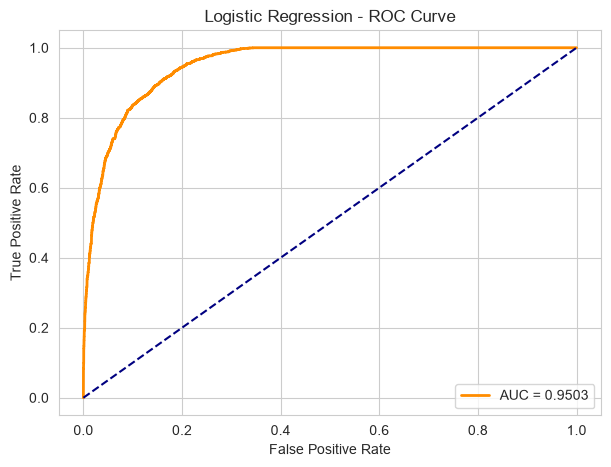

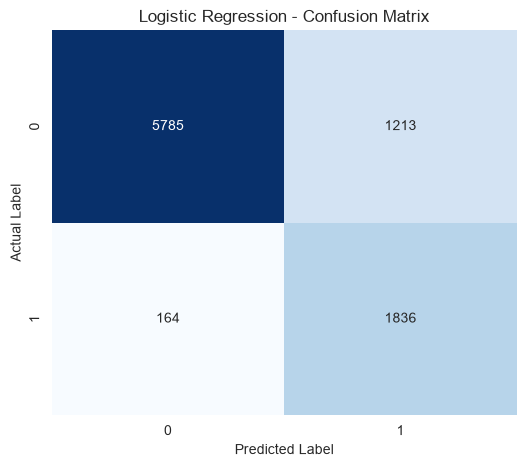

Accuracy   : 0.8470
Precision  : 0.6022
Recall     : 0.9180
F1 Score   : 0.7273
ROC-AUC    : 0.9503


In [39]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

evaluate_and_store("Logistic Regression", y_test, lr_pred, lr_prob)

### Logistic Regression Tuning


Logistic Regression Tuned


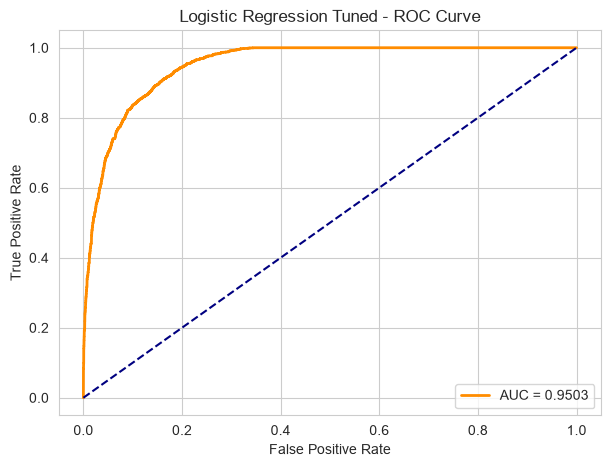

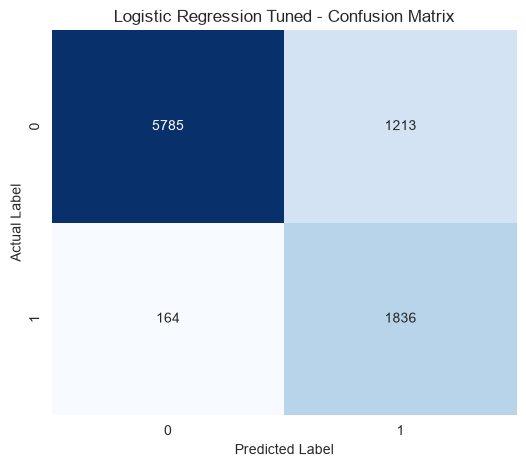

Accuracy   : 0.8470
Precision  : 0.6022
Recall     : 0.9180
F1 Score   : 0.7273
ROC-AUC    : 0.9503


In [40]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

lr_best_model = lr_grid.best_estimator_
lr_best_pred = lr_best_model.predict(X_test_scaled)
lr_best_prob = lr_best_model.predict_proba(X_test_scaled)[:, 1]

evaluate_and_store("Logistic Regression Tuned", y_test, lr_best_pred, lr_best_prob)

### Decision Tree


Decision Tree


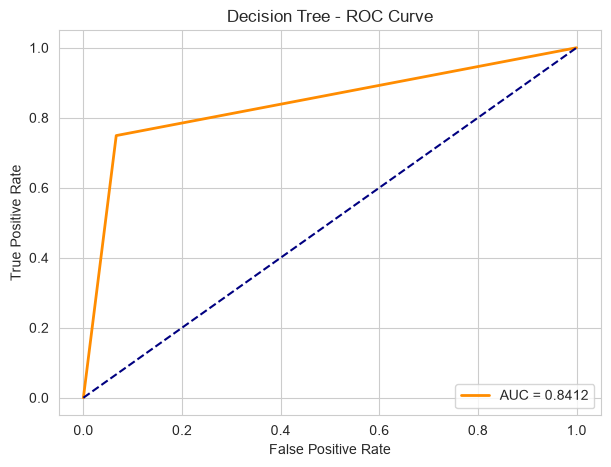

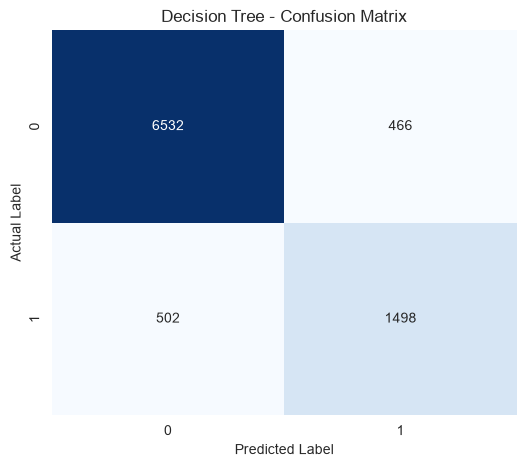

Accuracy   : 0.8924
Precision  : 0.7627
Recall     : 0.7490
F1 Score   : 0.7558
ROC-AUC    : 0.8412


In [41]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

evaluate_and_store("Decision Tree", y_test, dt_pred, dt_prob)

### Decision Tree Tuning


Decision Tree Tuned


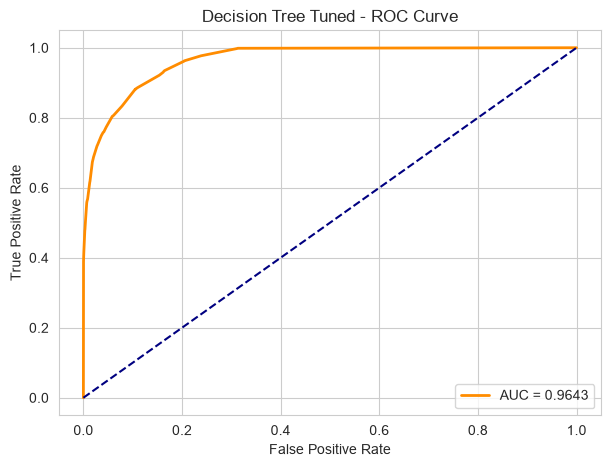

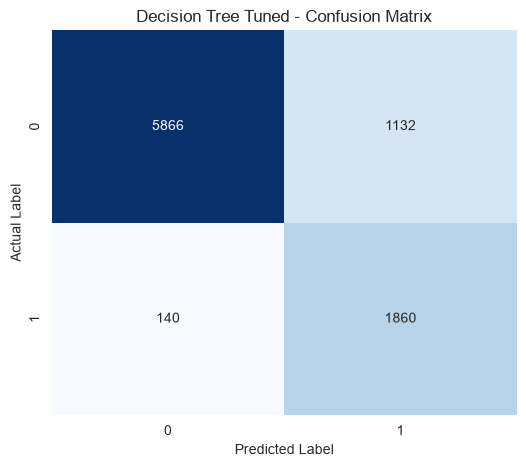

Accuracy   : 0.8586
Precision  : 0.6217
Recall     : 0.9300
F1 Score   : 0.7452
ROC-AUC    : 0.9643


In [42]:
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, 9, 11, 13, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    dt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_best_model = dt_grid.best_estimator_
dt_best_pred = dt_best_model.predict(X_test)
dt_best_prob = dt_best_model.predict_proba(X_test)[:, 1]

evaluate_and_store("Decision Tree Tuned", y_test, dt_best_pred, dt_best_prob)

### Random Forest


Random Forest


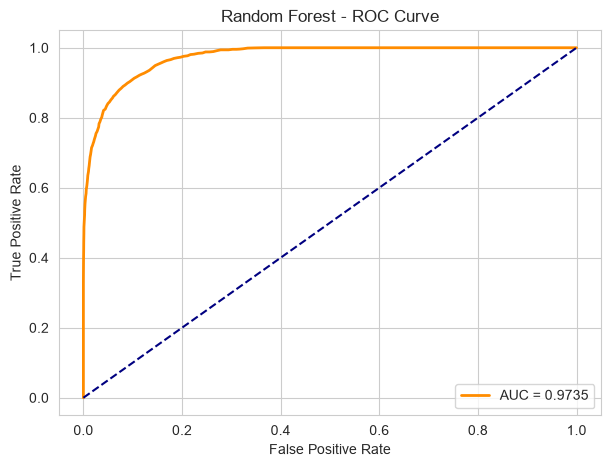

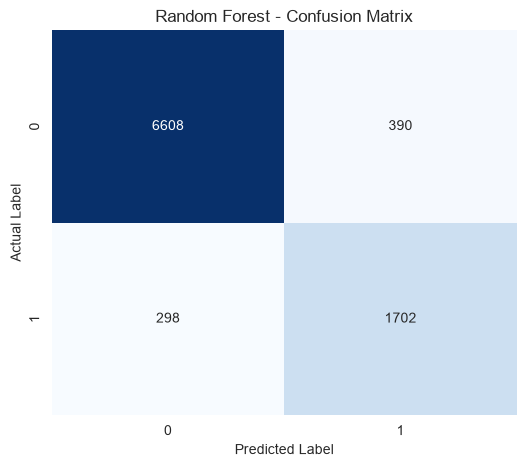

Accuracy   : 0.9235
Precision  : 0.8136
Recall     : 0.8510
F1 Score   : 0.8319
ROC-AUC    : 0.9735


In [43]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

evaluate_and_store("Random Forest", y_test, rf_pred, rf_prob)

### Random Forest Tuning


Random Forest Tuned


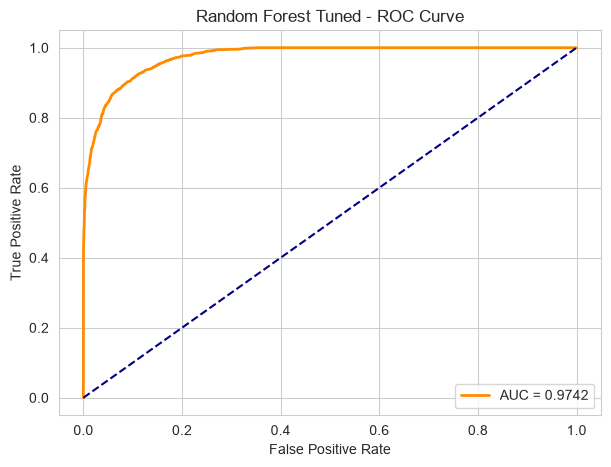

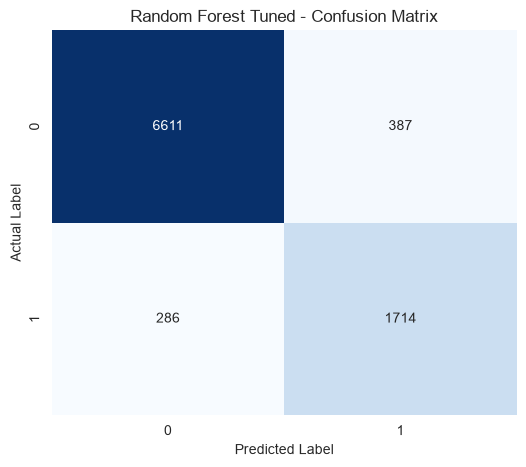

Accuracy   : 0.9252
Precision  : 0.8158
Recall     : 0.8570
F1 Score   : 0.8359
ROC-AUC    : 0.9742


In [44]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

rf_best_model = rf_grid.best_estimator_
rf_best_pred = rf_best_model.predict(X_test)
rf_best_prob = rf_best_model.predict_proba(X_test)[:, 1]

evaluate_and_store("Random Forest Tuned", y_test, rf_best_pred, rf_best_prob)

### XGBoost


XGBoost


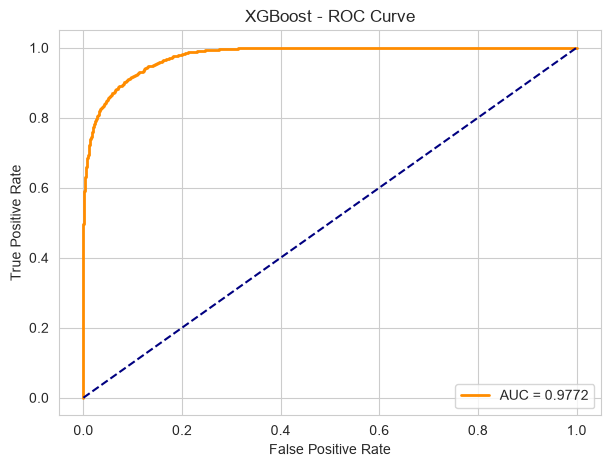

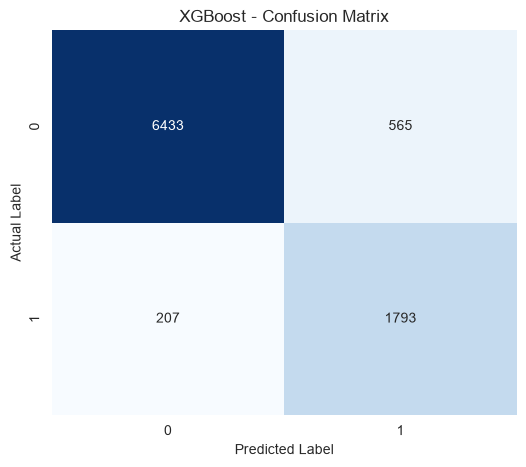

Accuracy   : 0.9142
Precision  : 0.7604
Recall     : 0.8965
F1 Score   : 0.8229
ROC-AUC    : 0.9772


In [45]:
scale_pos_weight_value = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_value
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

evaluate_and_store("XGBoost", y_test, xgb_pred, xgb_prob)

### XGBoost Tuning


XGBoost Tuned


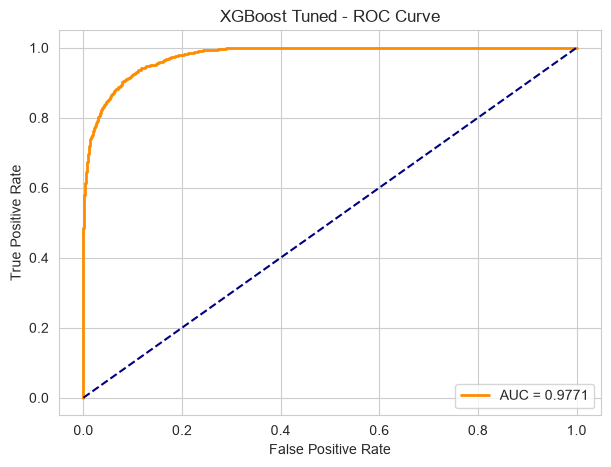

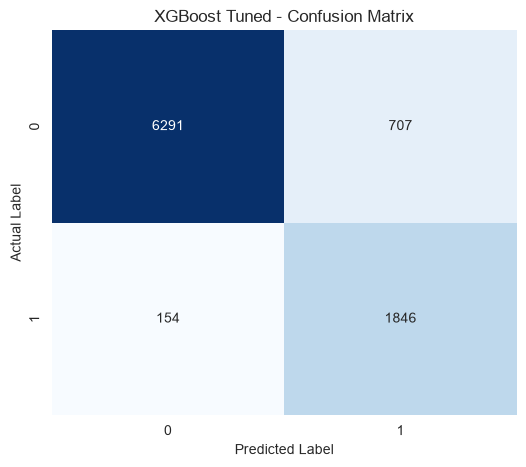

Accuracy   : 0.9043
Precision  : 0.7231
Recall     : 0.9230
F1 Score   : 0.8109
ROC-AUC    : 0.9771


In [46]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_value
    ),
    xgb_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_grid.fit(X_train, y_train)

xgb_best_model = xgb_grid.best_estimator_
xgb_best_pred = xgb_best_model.predict(X_test)
xgb_best_prob = xgb_best_model.predict_proba(X_test)[:, 1]

evaluate_and_store("XGBoost Tuned", y_test, xgb_best_pred, xgb_best_prob)

### LightGBM

[LightGBM] [Info] Number of positive: 8000, number of negative: 27992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1218
[LightGBM] [Info] Number of data points in the train set: 35992, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222272 -> initscore=-1.252477
[LightGBM] [Info] Start training from score -1.252477

LightGBM


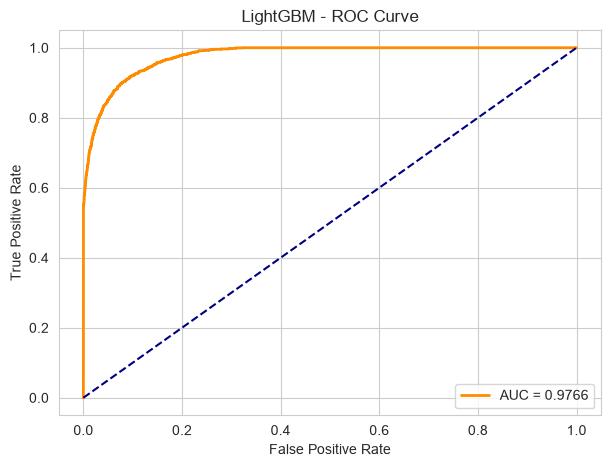

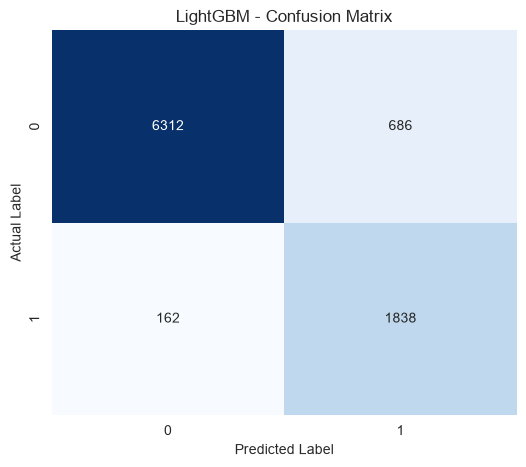

Accuracy   : 0.9058
Precision  : 0.7282
Recall     : 0.9190
F1 Score   : 0.8126
ROC-AUC    : 0.9766


In [47]:
lgbm_model = LGBMClassifier(random_state=42, is_unbalance=True)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

evaluate_and_store("LightGBM", y_test, lgbm_pred, lgbm_prob)

### LightGBM Tuning

[LightGBM] [Info] Number of positive: 8000, number of negative: 27992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1218
[LightGBM] [Info] Number of data points in the train set: 35992, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222272 -> initscore=-1.252477
[LightGBM] [Info] Start training from score -1.252477
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LightGBM Tuned


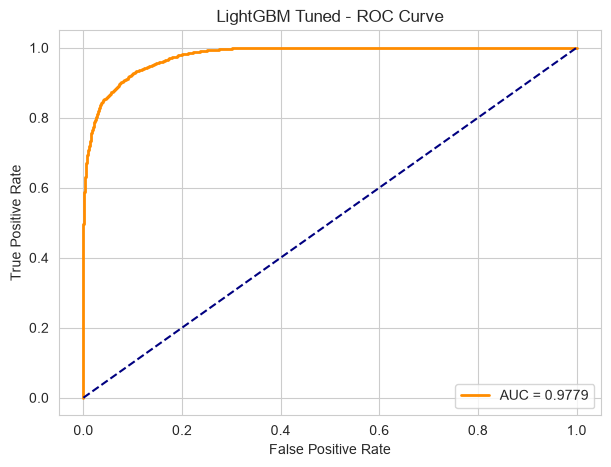

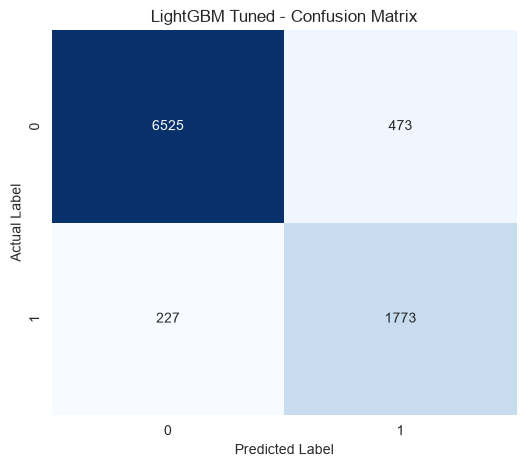

Accuracy   : 0.9222
Precision  : 0.7894
Recall     : 0.8865
F1 Score   : 0.8351
ROC-AUC    : 0.9779


In [49]:
lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "num_leaves": [31, 50, 70],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 10, 20]
}

lgbm_grid = RandomizedSearchCV(
    LGBMClassifier(random_state=42, is_unbalance=True),
    lgbm_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

lgbm_grid.fit(X_train, y_train)

lgbm_best_model = lgbm_grid.best_estimator_
lgbm_best_pred = lgbm_best_model.predict(X_test)
lgbm_best_prob = lgbm_best_model.predict_proba(X_test)[:, 1]

evaluate_and_store("LightGBM Tuned", y_test, lgbm_best_pred, lgbm_best_prob)

### CatBoost


CatBoost


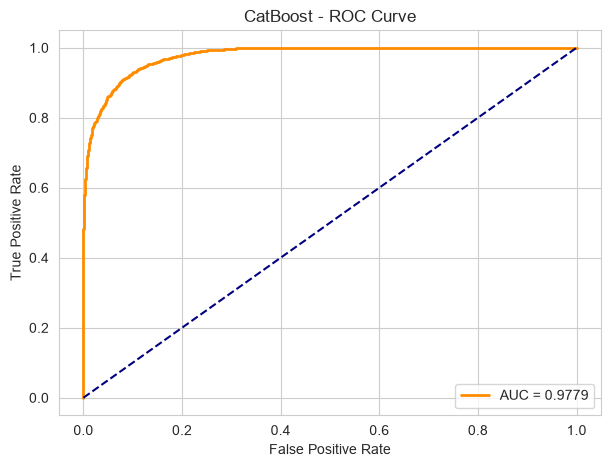

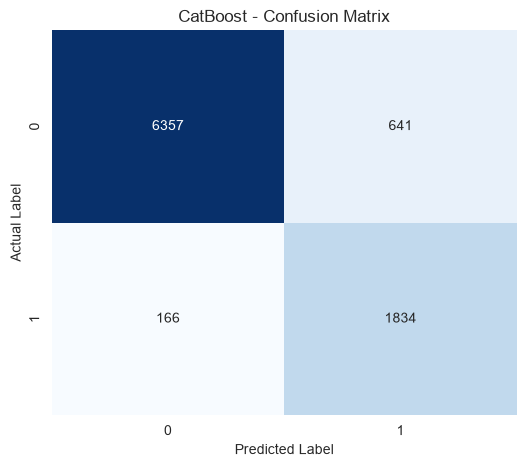

Accuracy   : 0.9103
Precision  : 0.7410
Recall     : 0.9170
F1 Score   : 0.8197
ROC-AUC    : 0.9779


In [54]:
class_weights_cat = [1.0, float(y_train.value_counts()[0] / y_train.value_counts()[1])]


cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42,
    class_weights=class_weights_cat
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)
cat_prob = cat_model.predict_proba(X_test)[:, 1]

evaluate_and_store("CatBoost", y_test, cat_pred, cat_prob)

### CatBoost Tuning


CatBoost Tuned


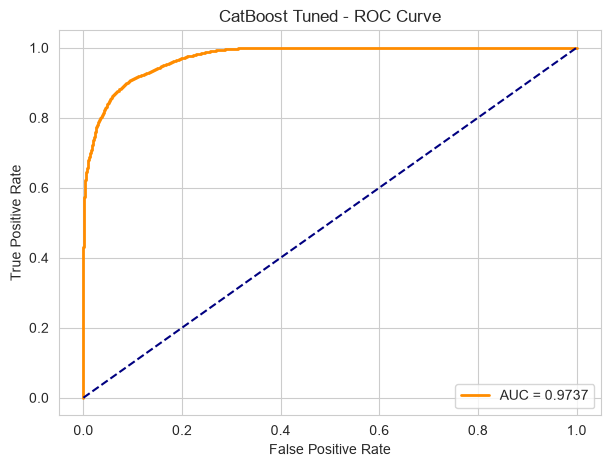

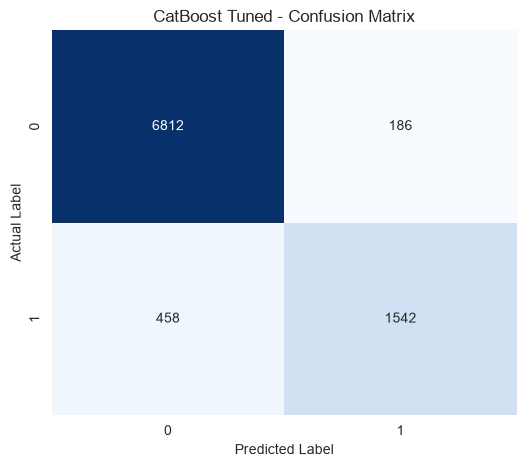

Accuracy   : 0.9284
Precision  : 0.8924
Recall     : 0.7710
F1 Score   : 0.8273
ROC-AUC    : 0.9737


In [56]:
cat_param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5]
}

cat_grid = RandomizedSearchCV(
    CatBoostClassifier(
        verbose=0,
        random_state=42,
    ),
    cat_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

cat_grid.fit(X_train, y_train)

cat_best_model = cat_grid.best_estimator_
cat_best_pred = cat_best_model.predict(X_test)
cat_best_prob = cat_best_model.predict_proba(X_test)[:, 1]

evaluate_and_store("CatBoost Tuned", y_test, cat_best_pred, cat_best_prob)

### Results table

In [57]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["ROC-AUC", "F1 Score", "Accuracy"], ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
9,LightGBM Tuned,0.922205,0.789403,0.8865,0.835139,0.977911
10,CatBoost,0.910313,0.741010,0.9170,0.819665,0.977903
11,CatBoost,0.910313,0.741010,0.9170,0.819665,0.977903
12,CatBoost,0.910313,0.741010,0.9170,0.819665,0.977903
6,XGBoost,0.914203,0.760390,0.8965,0.822855,0.977168
7,XGBoost Tuned,0.904312,0.723071,0.9230,0.810894,0.977082
8,LightGBM,0.905757,0.728209,0.9190,0.812555,0.976552
5,Random Forest Tuned,0.925206,0.815802,0.8570,0.835894,0.974226
13,CatBoost Tuned,0.928429,0.892361,0.7710,0.827253,0.973664
4,Random Forest,0.923539,0.813576,0.8510,0.831867,0.973545


### Best model selection

In [59]:
best_model_row = results_df.iloc[0]

print("=" * 70)
print("Best Model Selection")
print("=" * 70)
print(f"Selected Model : {best_model_row['Model']}")
print(f"Accuracy       : {best_model_row['Accuracy']:.4f}")
print(f"Precision      : {best_model_row['Precision']:.4f}")
print(f"Recall         : {best_model_row['Recall']:.4f}")
print(f"F1 Score       : {best_model_row['F1 Score']:.4f}")
print(f"ROC-AUC        : {best_model_row['ROC-AUC']:.4f}")

print("\nConclusion:")
print(
    f"Based on the overall comparison of Accuracy, Precision, Recall, "
    f"F1 Score, and ROC-AUC, {best_model_row['Model']} is selected as "
    f"the best-performing model for loan approval prediction."
)

Best Model Selection
Selected Model : LightGBM Tuned
Accuracy       : 0.9222
Precision      : 0.7894
Recall         : 0.8865
F1 Score       : 0.8351
ROC-AUC        : 0.9779

Conclusion:
Based on the overall comparison of Accuracy, Precision, Recall, F1 Score, and ROC-AUC, LightGBM Tuned is selected as the best-performing model for loan approval prediction.


### Map best model variable

In [60]:
model_map = {
    "Logistic Regression": lr_model,
    "Logistic Regression Tuned": lr_best_model,
    "Decision Tree": dt_model,
    "Decision Tree Tuned": dt_best_model,
    "Random Forest": rf_model,
    "Random Forest Tuned": rf_best_model,
    "XGBoost": xgb_model,
    "XGBoost Tuned": xgb_best_model,
    "LightGBM": lgbm_model,
    "LightGBM Tuned": lgbm_best_model,
    "CatBoost": cat_model,
    "CatBoost Tuned": cat_best_model
}

best_model = model_map[best_model_row["Model"]]
best_model_name = best_model_row["Model"]

### Stage 3

### Save final model

In [61]:
feature_columns = [
    "age",
    "gender",
    "education",
    "employee_experience",
    "home_onwership",
    "loan_amount",
    "loan_intent",
    "loan_interest_rate",
    "loan_percentage",
    "credit_history",
    "credit_score",
    "previous_loan",
    "person_income_log"
]

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

with open("best_model_name.pkl", "wb") as f:
    pickle.dump(best_model_name, f)

print("Stage 3 deployment files saved successfully.")

Stage 3 deployment files saved successfully.


### Deployment ready message

In [62]:
print("All required files for deployment are saved successfully.")
print("Next step: create app.py file using Streamlit.")

All required files for deployment are saved successfully.
Next step: create app.py file using Streamlit.
